# 🥗 AI Diet & Workout Recommendation System
## Machine Learning Pipeline and Classification Analysis

## Step 1 — Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay
import joblib

import warnings
warnings.filterwarnings('ignore')
print('All libraries imported successfully!')

All libraries imported successfully!


## Step 2 — Load Dataset

In [2]:
df = pd.read_csv('AI_Diet_Workout_Recommendation_Dataset_5000.csv')
print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (5000, 20)


,Age,Gender,Height_cm,Weight_kg,BMI,Goal,ActivityLevel,DietPreference,MedicalCondition,WorkoutExperience,SleepHours,WaterIntake_L,DailyCalories,WorkoutDays,Smoking,Alcohol,StressLevel,FoodAllergy,RecommendedDiet,RecommendedWorkout
0,56,Female,186,97,28.0,Maintain Weight,Sedentary,Vegetarian,No Medical Condition,Intermediate,9,1.9,2029,1,Yes,Frequently,High,NaN,Balanced Vegetarian Diet,Yoga + Walking
1,69,Male,162,62,23.6,Weight Loss,Active,Vegan,Diabetes,Beginner,9,3.3,1729,7,No,Never,Medium,Nuts,Diabetic Diet,Cardio + HIIT
2,46,Female,168,82,29.1,Maintain Weight,Moderate,Vegan,No Medical Condition,Intermediate,6,4.2,2292,7,No,Occasionally,Medium,NaN,Low Calorie Vegan Diet,Functional Training
3,32,Male,179,103,32.1,Maintain Weight,Active,Non-Vegetarian,Diabetes,Intermediate,5,4.0,3439,4,No,Never,Medium,NaN,Diabetic Diet,Mixed Fitness
4,60,Female,194,45,12.0,Muscle Gain,Active,Non-Vegetarian,No Medical Condition,Beginner,8,3.5,2372,4,Yes,Occasionally,High,Nuts,High Protein Diet,Yoga + Walking


## Step 3 — EDA

In [3]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Age                 5000 non-null   int64  
 1   Gender              5000 non-null   str    
 2   Height_cm           5000 non-null   int64  
 3   Weight_kg           5000 non-null   int64  
 4   BMI                 5000 non-null   float64
 5   Goal                5000 non-null   str    
 6   ActivityLevel       5000 non-null   str    
 7   DietPreference      5000 non-null   str    
 8   MedicalCondition    5000 non-null   str    
 9   WorkoutExperience   5000 non-null   str    
 10  SleepHours          5000 non-null   int64  
 11  WaterIntake_L       5000 non-null   float64
 12  DailyCalories       5000 non-null   int64  
 13  WorkoutDays         5000 non-null   int64  
 14  Smoking             5000 non-null   str    
 15  Alcohol             5000 non-null   str    
 16  StressLevel      

,Age,Height_cm,Weight_kg,BMI,SleepHours,WaterIntake_L,DailyCalories,WorkoutDays
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,46.672800,174.663800,82.090200,27.497880,7.006800,2.986900,2284.078600,3.480800
std,16.630005,14.640274,21.778387,8.749412,1.992975,1.151651,595.733636,2.302931
min,18.000000,150.000000,45.000000,11.200000,4.000000,1.000000,1200.000000,0.000000
25%,32.000000,162.000000,63.000000,20.600000,5.000000,2.000000,1854.750000,1.000000
50%,47.000000,174.000000,82.000000,26.800000,7.000000,3.000000,2263.500000,3.000000
75%,61.000000,187.000000,101.000000,33.100000,9.000000,4.000000,2693.000000,5.000000
max,75.000000,200.000000,120.000000,52.600000,10.000000,5.000000,4000.000000,7.000000


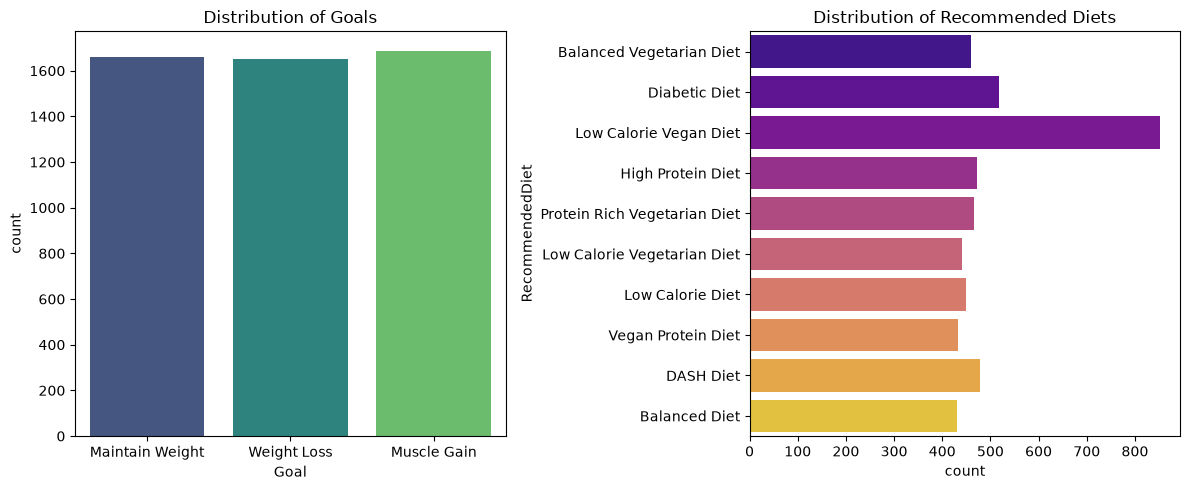

In [4]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.countplot(data=df, x='Goal', palette='viridis')
plt.title('Distribution of Goals')

plt.subplot(1, 2, 2)
sns.countplot(data=df, y='RecommendedDiet', palette='plasma')
plt.title('Distribution of Recommended Diets')
plt.tight_layout()
plt.show()

## Step 4 — Data Cleaning

In [5]:
print("Checking for missing values in all columns:")
print(df.isnull().sum())

Checking for missing values in all columns:
Age                      0
Gender                   0
Height_cm                0
Weight_kg                0
BMI                      0
Goal                     0
ActivityLevel            0
DietPreference           0
MedicalCondition         0
WorkoutExperience        0
SleepHours               0
WaterIntake_L            0
DailyCalories            0
WorkoutDays              0
Smoking                  0
Alcohol                  0
StressLevel              0
FoodAllergy           3405
RecommendedDiet          0
RecommendedWorkout       0
dtype: int64


## Step 5 — Outlier Detection & Treatment

In [6]:
numeric_cols = ['Age', 'Height_cm', 'Weight_kg', 'BMI', 'SleepHours', 'WaterIntake_L', 'DailyCalories', 'WorkoutDays']
print("Outlier check using IQR (outliers will be clipped):")
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_limit) | (df[col] > upper_limit)]
    print(f"{col}: Found {len(outliers)} outliers")
    df[col] = np.clip(df[col], lower_limit, upper_limit)

Outlier check using IQR (outliers will be clipped):
Age: Found 0 outliers
Height_cm: Found 0 outliers
Weight_kg: Found 0 outliers
BMI: Found 7 outliers
SleepHours: Found 0 outliers
WaterIntake_L: Found 0 outliers
DailyCalories: Found 9 outliers
WorkoutDays: Found 0 outliers


## Step 6 — Encoding

In [7]:
features = [
    'Age', 'Gender', 'Height_cm', 'Weight_kg', 'BMI', 'Goal', 'ActivityLevel', 
    'DietPreference', 'MedicalCondition', 'WorkoutExperience', 'SleepHours', 
    'WaterIntake_L', 'DailyCalories', 'WorkoutDays', 'Smoking', 'Alcohol', 
    'StressLevel', 'FoodAllergy'
]

X = df[features]
y_diet = df['RecommendedDiet']
y_workout = df['RecommendedWorkout']

numeric_features = ['Age', 'Height_cm', 'Weight_kg', 'BMI', 'SleepHours', 'WaterIntake_L', 'DailyCalories', 'WorkoutDays']
categorical_features = ['Gender', 'Goal', 'ActivityLevel', 'DietPreference', 'MedicalCondition', 'WorkoutExperience', 'Smoking', 'Alcohol', 'StressLevel', 'FoodAllergy']

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

X_encoded = preprocessor.fit_transform(X)
print("Feature matrix shape after encoding & scaling:", X_encoded.shape)

Feature matrix shape after encoding & scaling: (5000, 38)


## Step 7 — Train-Test Split

In [8]:
X_train_diet, X_test_diet, y_train_diet, y_test_diet = train_test_split(X, y_diet, test_size=0.2, random_state=42, stratify=y_diet)
X_train_workout, X_test_workout, y_train_workout, y_test_workout = train_test_split(X, y_workout, test_size=0.2, random_state=42, stratify=y_workout)
print("Train and Test split completed successfully!")

Train and Test split completed successfully!


## Step 8 — Train 5 ML Models

In [9]:
diet_models = {
    'LogisticRegression': Pipeline([('prep', preprocessor), ('clf', LogisticRegression(max_iter=1000, random_state=42))]),
    'DecisionTreeClassifier': Pipeline([('prep', preprocessor), ('clf', DecisionTreeClassifier(random_state=42))]),
    'RandomForestClassifier': Pipeline([('prep', preprocessor), ('clf', RandomForestClassifier(random_state=42))]),
    'KNeighborsClassifier': Pipeline([('prep', preprocessor), ('clf', KNeighborsClassifier())]),
    'SVC': Pipeline([('prep', preprocessor), ('clf', SVC(probability=True, random_state=42))])
}

for name, model in diet_models.items():
    model.fit(X_train_diet, y_train_diet)
    print(f"Diet Model - {name} trained successfully!")

Diet Model - LogisticRegression trained successfully!
Diet Model - DecisionTreeClassifier trained successfully!
Diet Model - RandomForestClassifier trained successfully!
Diet Model - KNeighborsClassifier trained successfully!
Diet Model - SVC trained successfully!


In [10]:
workout_models = {
    'LogisticRegression': Pipeline([('prep', preprocessor), ('clf', LogisticRegression(max_iter=1000, random_state=42))]),
    'DecisionTreeClassifier': Pipeline([('prep', preprocessor), ('clf', DecisionTreeClassifier(random_state=42))]),
    'RandomForestClassifier': Pipeline([('prep', preprocessor), ('clf', RandomForestClassifier(random_state=42))]),
    'KNeighborsClassifier': Pipeline([('prep', preprocessor), ('clf', KNeighborsClassifier())]),
    'SVC': Pipeline([('prep', preprocessor), ('clf', SVC(probability=True, random_state=42))])
}

for name, model in workout_models.items():
    model.fit(X_train_workout, y_train_workout)
    print(f"Workout Model - {name} trained successfully!")

Workout Model - LogisticRegression trained successfully!
Workout Model - DecisionTreeClassifier trained successfully!
Workout Model - RandomForestClassifier trained successfully!
Workout Model - KNeighborsClassifier trained successfully!
Workout Model - SVC trained successfully!


## Step 9 — Compare Models

In [11]:
print("Diet Model Test Accuracy Results:")
for name, model in diet_models.items():
    acc = accuracy_score(y_test_diet, model.predict(X_test_diet))
    print(f"{name}: {acc:.4f}")

Diet Model Test Accuracy Results:
LogisticRegression: 0.9850
DecisionTreeClassifier: 0.9610
RandomForestClassifier: 0.9850
KNeighborsClassifier: 0.6670
SVC: 0.9850


In [12]:
print("Workout Model Test Accuracy Results:")
for name, model in workout_models.items():
    acc = accuracy_score(y_test_workout, model.predict(X_test_workout))
    print(f"{name}: {acc:.4f}")

Workout Model Test Accuracy Results:
LogisticRegression: 0.9250
DecisionTreeClassifier: 0.9600
RandomForestClassifier: 0.9870
KNeighborsClassifier: 0.6730
SVC: 0.9280


## Step 10 — Cross Validation

In [13]:
cv_strat = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

print("Diet Models Cross-Validation Score:")
for name, model in diet_models.items():
    scores = cross_val_score(model, X, y_diet, cv=cv_strat)
    print(f"{name}: {scores.mean():.4f}")

Diet Models Cross-Validation Score:
LogisticRegression: 0.9850
DecisionTreeClassifier: 0.9620
RandomForestClassifier: 0.9850
KNeighborsClassifier: 0.6672
SVC: 0.9850


In [14]:
print("Workout Models Cross-Validation Score:")
for name, model in workout_models.items():
    scores = cross_val_score(model, X, y_workout, cv=cv_strat)
    print(f"{name}: {scores.mean():.4f}")

Workout Models Cross-Validation Score:
LogisticRegression: 0.9182
DecisionTreeClassifier: 0.9556
RandomForestClassifier: 0.9800
KNeighborsClassifier: 0.6708
SVC: 0.9168


## Step 11 — Hyperparameter Tuning

In [15]:
grid_d = GridSearchCV(diet_models['LogisticRegression'], {'clf__C': [0.1, 1.0, 10.0]}, cv=cv_strat, scoring='accuracy', n_jobs=-1)
grid_d.fit(X_train_diet, y_train_diet)
print("Best Diet Parameters:", grid_d.best_params_)
print(f"Best Diet Accuracy: {grid_d.best_score_:.4f}")

Best Diet Parameters: {'clf__C': 0.1}
Best Diet Accuracy: 0.9850


In [16]:
grid_w = GridSearchCV(workout_models['RandomForestClassifier'], {'clf__n_estimators': [50, 100], 'clf__max_depth': [10, None]}, cv=cv_strat, scoring='accuracy', n_jobs=-1)
grid_w.fit(X_train_workout, y_train_workout)
print("Best Workout Parameters:", grid_w.best_params_)
print(f'Best Workout Accuracy: {grid_w.best_score_:.4f}')

Best Workout Parameters: {'clf__max_depth': None, 'clf__n_estimators': 100}
Best Workout Accuracy: 0.9780


## Step 12 — Final Model

In [17]:
final_diet_model = grid_d.best_estimator_
final_workout_model = grid_w.best_estimator_
print("Final model objects built!")

Final model objects built!


## Step 13 — Evaluation

In [18]:
print("Final Diet Model Test Evaluation:")
print(classification_report(y_test_diet, final_diet_model.predict(X_test_diet)))

Final Diet Model Test Evaluation:
                              precision    recall  f1-score   support

               Balanced Diet       0.99      0.99      0.99        86
    Balanced Vegetarian Diet       0.99      0.97      0.98        92
                   DASH Diet       0.96      0.99      0.97        96
               Diabetic Diet       0.96      1.00      0.98       104
           High Protein Diet       1.00      0.99      0.99        95
            Low Calorie Diet       0.99      1.00      0.99        90
      Low Calorie Vegan Diet       0.98      0.98      0.98       170
 Low Calorie Vegetarian Diet       0.99      0.99      0.99        88
Protein Rich Vegetarian Diet       1.00      0.98      0.99        93
          Vegan Protein Diet       1.00      0.97      0.98        86

                    accuracy                           0.98      1000
                   macro avg       0.99      0.98      0.99      1000
                weighted avg       0.99      0.98     

In [19]:
print("Final Workout Model Test Evaluation:")
print(classification_report(y_test_workout, final_workout_model.predict(X_test_workout)))

Final Workout Model Test Evaluation:
                     precision    recall  f1-score   support

      Cardio + HIIT       0.97      0.97      0.97        63
   Fat Burn Workout       1.00      0.98      0.99        95
Functional Training       0.97      0.99      0.98        76
      Mixed Fitness       0.96      0.98      0.97        45
     Push Pull Legs       0.99      0.97      0.98       100
  Running + Cycling       1.00      0.99      0.99        90
  Strength Training       0.99      1.00      0.99       151
     Yoga + Walking       0.99      0.99      0.99       380

           accuracy                           0.99      1000
          macro avg       0.98      0.98      0.98      1000
       weighted avg       0.99      0.99      0.99      1000



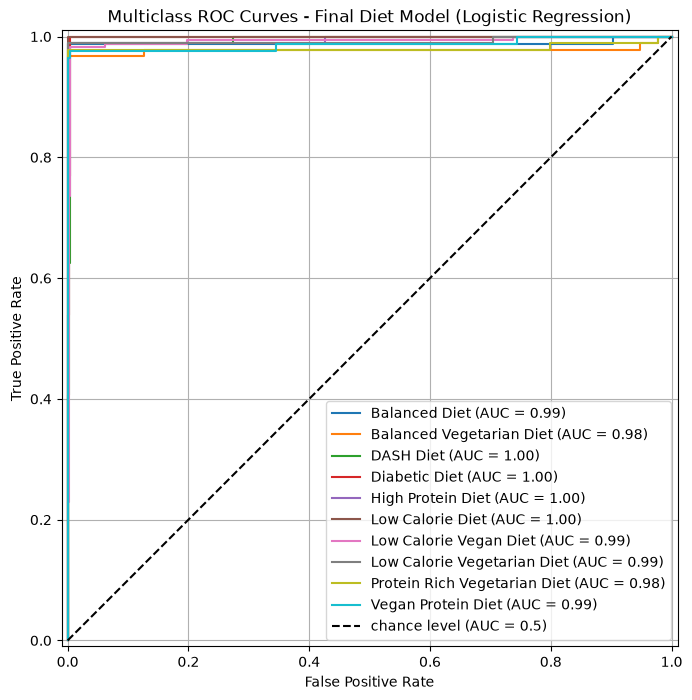

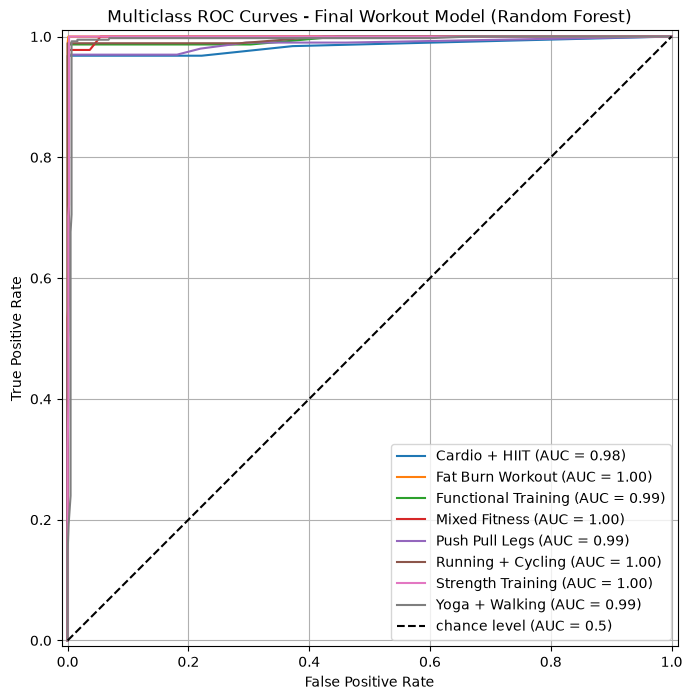

In [20]:
# Multi-class ROC Curve plots
from sklearn.preprocessing import LabelBinarizer

def plot_multiclass_roc(model, X_test, y_test, title):
    classes = list(model.classes_)
    n_classes = len(classes)
    lb = LabelBinarizer()
    y_test_bin = lb.fit_transform(y_test)
    y_score = model.predict_proba(X_test)
    
    plt.figure(figsize=(10, 8))
    for i in range(n_classes):
        RocCurveDisplay.from_predictions(
            y_test_bin[:, i],
            y_score[:, i],
            name=f"{classes[i]}",
            ax=plt.gca()
        )
    plt.plot([0, 1], [0, 1], 'k--', label='chance level (AUC = 0.5)')
    plt.title(f'Multiclass ROC Curves - {title}')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend(loc='best')
    plt.grid(True)
    plt.show()

plot_multiclass_roc(final_diet_model, X_test_diet, y_test_diet, "Final Diet Model (Logistic Regression)")
plot_multiclass_roc(final_workout_model, X_test_workout, y_test_workout, "Final Workout Model (Random Forest)")

## Step 14 — Single Prediction

In [21]:
sample_input = pd.DataFrame([X.iloc[0]])
print("Sample user features:")
print(sample_input)

print("\nPredicted Diet:", final_diet_model.predict(sample_input)[0])
print("Predicted Workout:", final_workout_model.predict(sample_input)[0])

Sample user features:
   Age  Gender  Height_cm  Weight_kg   BMI             Goal ActivityLevel  \
0   56  Female        186         97  28.0  Maintain Weight     Sedentary   

  DietPreference      MedicalCondition WorkoutExperience  SleepHours  \
0     Vegetarian  No Medical Condition      Intermediate           9   

   WaterIntake_L  DailyCalories  WorkoutDays Smoking     Alcohol StressLevel  \
0            1.9         2029.0            1     Yes  Frequently        High   

   FoodAllergy  
0          NaN  

Predicted Diet: Balanced Vegetarian Diet
Predicted Workout: Yoga + Walking


## Step 15 — Save Model & Encoders

In [22]:
joblib.dump(final_diet_model, 'best_diet_pipeline.joblib')
joblib.dump(final_workout_model, 'best_workout_pipeline.joblib')
print('Best pipelines successfully saved to disk!')

Best pipelines successfully saved to disk!
